In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
import json
import pandas as pd

#### Load HPC experimental data

In [2]:

with open("qpte_scaling.json") as f:
    data = json.load(f)

# Flatten the data
rows = []
for entry in data:
    rows.append({
        "cpus": entry["cpus"],
        "block_size": entry["block_size"],
        "mean": pd.Series(entry["times"]).mean(),
        "std": pd.Series(entry["times"]).std()
    })

df = pd.DataFrame(rows)



#### Plot Scaling tests

In [3]:


def plot_scaling_combined(
    df,
    reference_time=6.485,
    savepath=None,
    logy=True,
    logx_cpu=True,
    logx_block=True,
    mode="color",
    cmap="Dark2"
):
    """
    Combined figure with two panels:
      (left)  Time vs Block Size (one curve per CPU)
      (right) Time vs CPUs       (one curve per Block Size)

    Consistent styling across panels:
      - color encodes CPU count
      - marker encodes block size
    """

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 14,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.linewidth": 1.2
    })

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(16, 5.5),
        sharey=True
    )

    cpu_list = sorted(df["cpus"].unique())
    block_list = sorted(df["block_size"].unique())

    # common line style for all traces
    base_linewidth = 1.2
    base_linestyle = (0, (4, 3))
    base_alpha = 0.90

    # ----------------------------
    # Style mappings (consistent!)
    # ----------------------------
    if mode == "color":
        cmap_obj = plt.get_cmap(cmap)

        cpu_color_map = {
            cpu: cmap_obj(i % cmap_obj.N)
            for i, cpu in enumerate(cpu_list)
        }

        ref_color = "darkred"
        shade_color = "lightgreen"

    elif mode == "bw":
        cpu_color_map = {cpu: "0.4" for cpu in cpu_list}
        ref_color = "black"
        shade_color = "0.2"

    else:
        raise ValueError("mode must be 'color' or 'bw'")

    markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h", "<", ">"]
    block_marker_map = {
        bs: markers[i % len(markers)]
        for i, bs in enumerate(block_list)
    }

    # marker face colors
    if mode == "bw":
        gray_levels = ["0.85", "0.75", "0.65", "0.55", "0.45", "0.35"]
        block_face_map = {
            bs: gray_levels[i % len(gray_levels)]
            for i, bs in enumerate(block_list)
        }
    else:
        # in color mode marker face follows CPU color
        block_face_map = None
    
    if logy:
        ax1.set_yscale("log")
        ax2.set_yscale("log")

    # ----------------------------
    # LEFT PANEL: x = block_size
    # ----------------------------
    for cpu in cpu_list:
        subset = df[df["cpus"] == cpu].sort_values("block_size")

        ax1.errorbar(
            subset["block_size"],
            subset["mean"],
            yerr=subset["std"],
            capsize=4.5,
            elinewidth=0.9,
            capthick=1.0,
            linestyle=base_linestyle,
            linewidth=base_linewidth,
            alpha=base_alpha,
            zorder=3,
            color=cpu_color_map[cpu],

            marker="o",                 # overridden point-by-point below
            markersize=1,
            markeredgewidth=2.2,
            markeredgecolor="black"
        )

        # overlay markers with correct block encoding
        for _, row in subset.iterrows():
            bs = row["block_size"]
            m = block_marker_map[bs]

            face = block_face_map[bs] if mode == "bw" else cpu_color_map[cpu]

            ax1.plot(
                row["block_size"],
                row["mean"],
                marker=m,
                markersize=10,
                markerfacecolor=face,
                markeredgecolor="black",
                markeredgewidth=2.2,
                linestyle="None",
                zorder=4
            )


    if not logx_block:
        plt.setp(ax1.get_xticklabels(), rotation=90, ha="right")

    if logx_block:
        ax1.set_xscale("log")
    ax1.set_xlabel("Block Size")
    ax1.set_title("Scaling vs Block Size")
    ax1.title.set_fontweight('bold')

    # ticks: only used block sizes
    ax1.set_xticks(block_list)
    ax1.minorticks_off()
    ax1.xaxis.set_major_formatter(ScalarFormatter())
    ax1.ticklabel_format(axis="x", style="plain")


    # ----------------------------
    # RIGHT PANEL: x = cpus
    # ----------------------------
    for bs in block_list:
        subset = df[df["block_size"] == bs].sort_values("cpus")

        ax2.errorbar(
            subset["cpus"],
            subset["mean"],
            yerr=subset["std"],
            capsize=4.5,
            elinewidth=0.9,
            capthick=1.0,
            linestyle=base_linestyle,
            linewidth=base_linewidth,
            alpha=base_alpha,
            zorder=3,

            color="0.4" if mode == "bw" else "0.5",  # line kept neutral here

            marker=block_marker_map[bs],
            markersize=10,
            markeredgewidth=2.2,
            markeredgecolor="black",
            markerfacecolor=(block_face_map[bs] if mode == "bw" else "white")
        )

        # overlay colored markers per CPU (so color still encodes CPU)
        if mode == "color":
            for _, row in subset.iterrows():
                cpu = row["cpus"]

                ax2.plot(
                    row["cpus"],
                    row["mean"],
                    marker=block_marker_map[bs],
                    markersize=10,
                    markerfacecolor=cpu_color_map[cpu],
                    markeredgecolor="black",
                    markeredgewidth=2.2,
                    linestyle="None",
                    zorder=4
                )

    if not logx_cpu:
        plt.setp(ax2.get_xticklabels(), rotation=90, ha="right")

    if logx_cpu:
        ax2.set_xscale("log")

    ax2.set_xlabel("CPUs")
    ax2.set_title("Scaling vs CPU Count")
    ax2.title.set_fontweight('bold')

    cpu_ticks = sorted(df["cpus"].unique())
    ax2.set_xticks(cpu_ticks)
    ax2.minorticks_off()
    ax2.xaxis.set_major_formatter(ScalarFormatter())
    ax2.ticklabel_format(axis="x", style="plain")

    # ----------------------------
    # Shared Y settings
    # ----------------------------
    ax1.set_ylabel("Time (s)")


    # grid: y only
    for ax in (ax1, ax2):
        ax.grid(True, which="major", axis="y", alpha=0.25)
        ax.grid(True, which="minor", axis="y", alpha=0.12)

    # extend y-axis upward slightly
    ymin, ymax = ax1.get_ylim()
    ax1.set_ylim(ymin*6, ymax * 1.0)

    # shaded real-time zone + reference line on both panels
    for ax in (ax1, ax2):
        ymin, ymax = ax.get_ylim()

        ax.axhspan(
            ymin,
            reference_time,
            facecolor=shade_color,
            alpha=0.22,
            zorder=0
        )

        ax.axhline(
            y=reference_time,
            color=ref_color,
            linestyle="-",
            linewidth=2.4,
            alpha=1,
            zorder=2
        )

    # ----------------------------
    # Legends (clean + separated)
    # ----------------------------

    # CPU legend (color encoding) -> figure-level legend at top
    cpu_handles = [
        Line2D(
            [0], [0],
            color=cpu_color_map[cpu],
            linestyle="-",
            linewidth=10.0,   # thick so it looks like a color swatch
            label=f"{cpu}"
        )
        for cpu in cpu_list
    ]

        # Reference + real-time zone legend -> inside right subplot
    ref_handle = Line2D(
        [0], [0],
        color=ref_color,
        linewidth=2.4,
        linestyle="-",
        label=fr"Audio Duration ({reference_time:.2f}s)"
    )

    rt_handle = Line2D(
        [0], [0],
        color=shade_color,
        linewidth=10,
        alpha=0.22,
        label="Real Time Zone"
    )
    # cpu_leg = fig.legend(
    #     handles=cpu_handles,
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, 1.10),
    #     ncol=min(8, len(cpu_handles)),
    #     frameon=False,
    #     columnspacing=1.4,
    #     handletextpad=0.6,
    #     handlelength=2.0,
    #     labelspacing=0.7,
    #     title="CPUs"
    # )
    # cpu_leg.get_title().set_fontsize(13)

    block_handles = [
        Line2D(
            [0], [0],
            color="black",
            linestyle="None",
            marker=block_marker_map[bs],
            markersize=9,
            markerfacecolor=(block_face_map[bs] if mode == "bw" else "white"),
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=f"{bs}"
        )
        for bs in block_list
    ]

    # # Block legend (second row)
    # block_leg = fig.legend(
    #     handles=block_handles + [ref_handle, rt_handle],
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, 1.),
    #     ncol=min(10, len(block_handles) + 2),
    #     frameon=False,
    #     columnspacing=1.2,
    #     handletextpad=0.6,
    #     labelspacing=0.7,
    #     title="Block Size / Reference"
    # )
    # block_leg.get_title().set_fontsize(13)


    # ----------------------------
    # Legends (3 stacked rows)
    # ----------------------------
    cpu_title = Line2D([], [], linestyle="None", label="CPUs:")
    cpu_leg = fig.legend(
        handles=[cpu_title]+cpu_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.085),
        ncol=min(9, len(cpu_handles)+1),
        frameon=False,
        columnspacing=1.4,
        handletextpad=1,
        handlelength=1.5,
        # handleheight=2,
        labelspacing=0.7,
    )
    cpu_leg.get_texts()[0].set_fontsize(13)
    cpu_leg.get_texts()[0].set_fontweight("semibold")
    
    
    block_title = Line2D([], [], linestyle="None", label="Block Size:")
    block_leg = fig.legend(
        handles=[block_title] + block_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=min(10, len(block_handles)+1),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        labelspacing=0.7,
    )
    block_leg.get_texts()[0].set_fontsize(13)
    block_leg.get_texts()[0].set_fontweight("semibold")
    
    
    ref_title = Line2D([], [], linestyle="None", label="Input Audio:")
    ref_leg = fig.legend(
        handles=[ref_title] + [ref_handle, rt_handle],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.975),
        ncol=2+1,
        frameon=False,
        columnspacing=2.0,
        handletextpad=0.8,
        handlelength=2.5
    )
    ref_leg.get_texts()[0].set_fontsize(13)
    ref_leg.get_texts()[0].set_fontweight("semibold")


    # ref_leg = ax2.legend(
    #     handles=[ref_handle, rt_handle],
    #     loc="lower right",
    #     frameon=False,
    #     borderaxespad=0.6,
    #     handlelength=2.2,
    #     labelspacing=0.6
    # )

    # keep both subplot legends visible
    # fig.add_artist(block_leg)
 

    fig.suptitle(
        "2nd Derivative Kernel QPTE Convolution - Strong Scaling",
        y=1.13,
        fontsize=18,
        fontweight='bold'
    )
    # fig.set_fontweight("bold")   
    plt.tight_layout(rect=[0, 0, 1, 1])

    if savepath is not None:
        plt.savefig(savepath, dpi=600, format="pdf", bbox_inches="tight")

    plt.show()


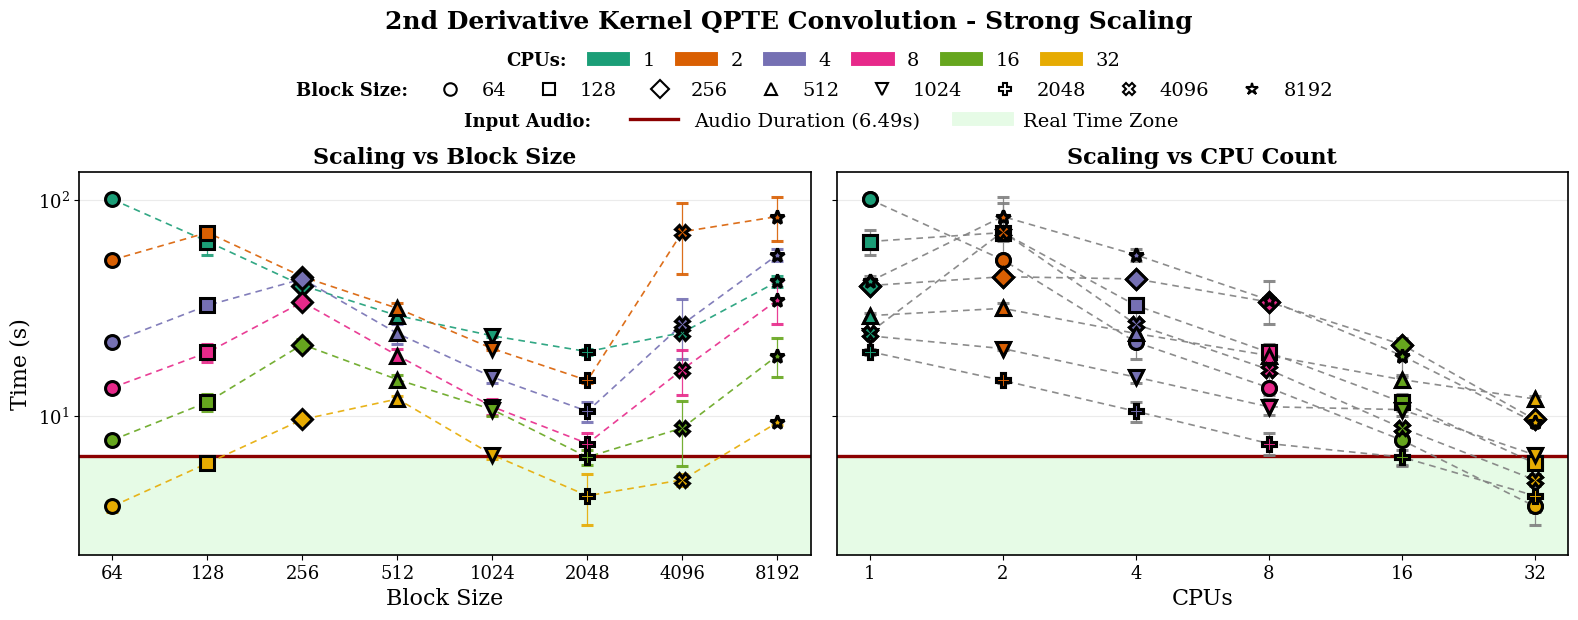

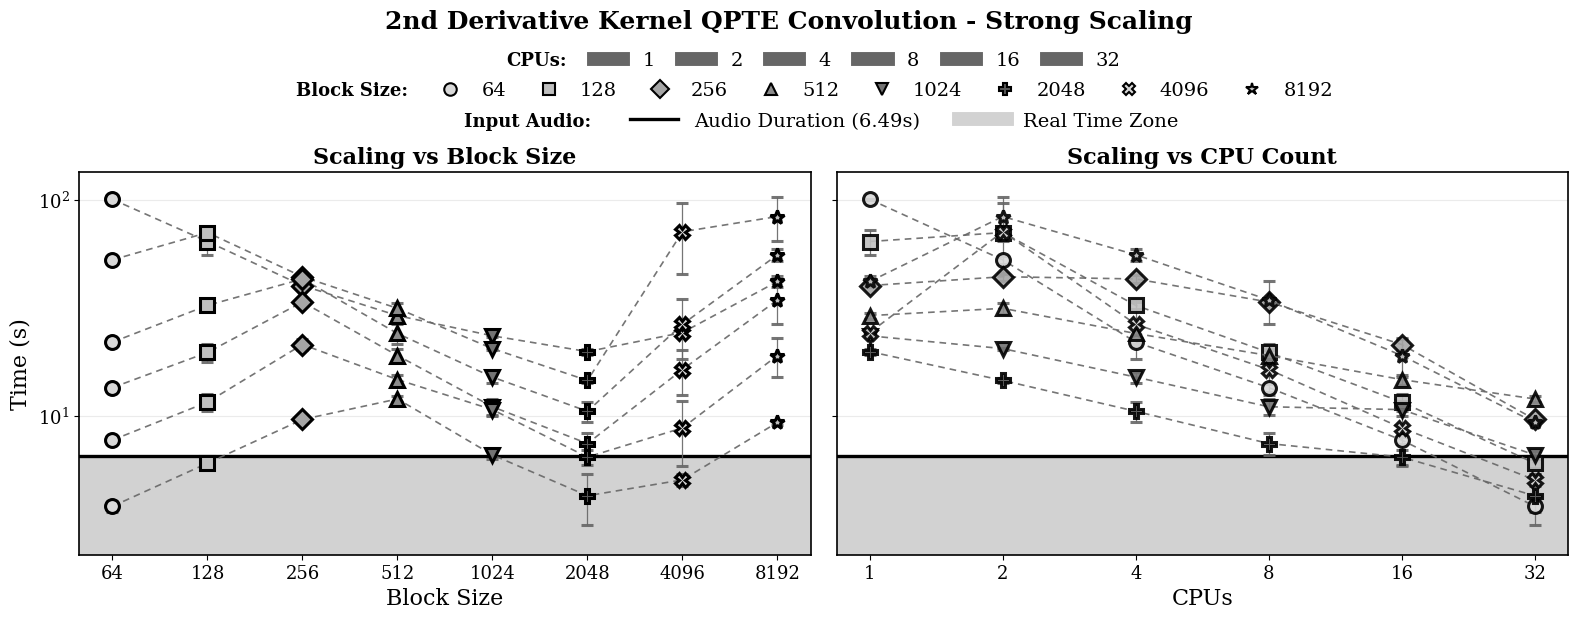

In [4]:
plot_scaling_combined(df, mode="color", cmap="Dark2", savepath='strong_scaling.pdf')
plot_scaling_combined(df, mode="bw")
